In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
import joblib

from imblearn.over_sampling import SMOTE

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

Saving EnviroBirth PreBEnvBD Dataset-Driven Prediction.csv to EnviroBirth PreBEnvBD Dataset-Driven Prediction.csv


In [ ]:

df = pd.read_csv(list(uploaded.keys())[0])

print("Shape:", df.shape)
print("Columns:", df.columns)
df.head()

Shape: (73000, 59)
Columns: Index(['Address', 'Latitude', 'Longitude', 'SO2', 'NO2', 'CO', 'O3', 'PM2.5',
       'PM10', 'CASEID', 'BIDX', 'Birth_Order', 'Multiple_Birth',
       'Preceding_Birth_Interval', 'Succeeding_Birth_Interval',
       'Gestational_Duration', 'Mother_Age', 'Education', 'Wealth_Index',
       'Drinking_Water_Source', 'Toilet_Type', 'Electricity', 'Cooking_Fuel',
       'Usual_Residents', 'Sleeping_Rooms', 'Place_of_Delivery',
       'Multiple_Birth.1', 'Child_Alive', 'Age_at_Death_Days',
       'Age_at_Death_Months', 'Gestation_Months', 'Pregnancy_Duration',
       'Birth_Size_Reported', 'Birth_Weight_Reported', 'Mother_Age.1',
       'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Delivery_Assistance',
       'Csection_Delivery', 'Iron_Supplement', 'BP_Checked', 'Urine_Test',
       'Blood_Test', 'Ultrasound', 'Weight_Measured', 'Height_Measured',
       'Stomach_Exam', 'Fetal_heartbeat', 'Blood_Pressure_Test',
       'Cooking_Location', 'Separate_Kitchen', 'Ha

,Address,Latitude,Longitude,SO2,NO2,CO,O3,PM2.5,PM10,CASEID,...,Blood_Pressure_Test,Cooking_Location,Separate_Kitchen,Has_Mosquito_Net,Number_Mosquito_Nets,Children_Using_Nets,Rainfall,Humidity,Temperature,Preterm
0,"Uttara, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.059,1.2,0.0525,57,73,0100 1 4,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,78.0,20.1,0
1,"Jatrabari, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.058,1.2,0.0525,59,71,0100 11 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,79.0,21.0,1
2,"Kuril Bishow Road, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,59,70,0102 3 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,82.0,20.1,0
3,"Mohakhali, Dhaka, Bangladesh,",23.820612,90.421011,0.04,0.056,1.2,0.0525,58,70,0102 8 1,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,73.0,21.0,0
4,"Dhanmondi, Dhaka, Bangladesh)",23.820612,90.421011,0.03,0.051,1.2,0.0525,61,69,0104 4 2,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,67.0,20.3,0


In [ ]:
env_features = ["SO2","NO2","CO","O3","PM2.5","PM10","Rainfall","Humidity","Temperature"]
maternal_features = ["Mother_Age","Mother_Height","Mother_Weight","Mother_BMI","Gestation_Months","Birth_Weight_Reported"]
household_features = ["Education","Wealth_Index","Drinking_Water_Source","Toilet_Type","Cooking_Fuel","Cooking_Location","Separate_Kitchen","Electricity","Has_Mosquito_Net"]
drop_cols = ["CASEID","BIDX","Address","Latitude","Longitude"]
features = env_features + maternal_features + household_features


In [ ]:
selected = [c for c in (env_features + maternal_features + household_features) if c in df.columns]
print("Selected features (will use):", selected)
target = "Preterm"
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in df.columns")

Selected features (will use): ['SO2', 'NO2', 'CO', 'O3', 'PM2.5', 'PM10', 'Rainfall', 'Humidity', 'Temperature', 'Mother_Age', 'Mother_Height', 'Mother_Weight', 'Mother_BMI', 'Gestation_Months', 'Birth_Weight_Reported', 'Education', 'Wealth_Index', 'Drinking_Water_Source', 'Toilet_Type', 'Cooking_Fuel', 'Cooking_Location', 'Separate_Kitchen', 'Electricity', 'Has_Mosquito_Net']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import numpy as np


X = df[selected].copy()
y = df[target].copy()


if y.dtype == 'object' or y.dtype.name == 'category':
    tmp = y.astype(str).str.strip().str.lower()
    if set(tmp.unique()).issubset({'yes','no','y','n'}):
        y = tmp.map({'yes':1,'y':1,'no':0,'n':0})
    else:
        le_target = LabelEncoder()
        y = le_target.fit_transform(y.astype(str))


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


numeric_feats = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_feats = [c for c in selected if c not in numeric_feats]


empty_numeric = [c for c in numeric_feats if X_train[c].isna().all()]
if empty_numeric:
    print("Dropping fully empty numeric columns:", empty_numeric)
    X_train = X_train.drop(columns=empty_numeric)
    X_test = X_test.drop(columns=empty_numeric)
    numeric_feats = [c for c in numeric_feats if c not in empty_numeric]


num_imputer = SimpleImputer(strategy='median')
X_train[numeric_feats] = num_imputer.fit_transform(X_train[numeric_feats])
X_test[numeric_feats] = num_imputer.transform(X_test[numeric_feats])


if categorical_feats:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[categorical_feats] = cat_imputer.fit_transform(X_train[categorical_feats])
    X_test[categorical_feats] = cat_imputer.transform(X_test[categorical_feats])

    X_train_cat = X_train[categorical_feats].apply(lambda x: x.astype('category').cat.codes)
    X_test_cat = X_test[categorical_feats].apply(lambda x: x.astype('category').cat.codes)
else:
    X_train_cat = np.empty((X_train.shape[0], 0))
    X_test_cat = np.empty((X_test.shape[0], 0))
    print("No categorical features detected, skipping categorical imputation/encoding.")

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_feats])
X_test_num = scaler.transform(X_test[numeric_feats])






Dropping fully empty numeric columns: ['Birth_Weight_Reported']
No categorical features detected, skipping categorical imputation/encoding.


In [ ]:

num_imputer = SimpleImputer(strategy='median')
X_train[numeric_feats] = num_imputer.fit_transform(X_train[numeric_feats])
X_test[numeric_feats] = num_imputer.transform(X_test[numeric_feats])

if categorical_feats:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[categorical_feats] = cat_imputer.fit_transform(X_train[categorical_feats])
    X_test[categorical_feats] = cat_imputer.transform(X_test[categorical_feats])


    label_encoders = {}
    for col in categorical_feats:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
        label_encoders[col] = le
else:
    print("No categorical features detected!")


scaler = StandardScaler()
X_train[numeric_feats] = scaler.fit_transform(X_train[numeric_feats])
X_test[numeric_feats] = scaler.transform(X_test[numeric_feats])


No categorical features detected!


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TabDataset(Dataset):
    def __init__(self, X, y, cat_cols, num_cols):
        self.cats = X[cat_cols].values.astype("int64") if cat_cols else np.empty((len(X),0))
        self.nums = X[num_cols].values.astype("float32") if num_cols else np.empty((len(X),0))
        self.labels = y.values.astype("int64")
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.cats[idx], self.nums[idx], self.labels[idx]

train_dataset = TabDataset(X_train, y_train, categorical_feats, numeric_feats)
test_dataset = TabDataset(X_test, y_test, categorical_feats, numeric_feats)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


In [ ]:
import torch.nn as nn

class TabTransformer(nn.Module):
    def __init__(self, categories, num_continuous, dim=32, depth=4, heads=8, dropout=0.1):
        super().__init__()
        self.cat_embeds = nn.ModuleList([nn.Embedding(c, dim) for c in categories])
        self.num_linear = nn.Linear(num_continuous, dim) if num_continuous > 0 else None

        encoder_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.fc = nn.Sequential(
            nn.Linear(dim * (len(categories) + (1 if num_continuous > 0 else 0)), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x_cats, x_nums):
        if len(x_cats.shape) == 1:
            x_cats = x_cats.unsqueeze(1)

        cat_embeds = [emb(x_cats[:, i]) for i, emb in enumerate(self.cat_embeds)]
        if cat_embeds:
            cat_embeds = torch.stack(cat_embeds, dim=1)
            trans_out = self.transformer(cat_embeds)
        else:
            trans_out = torch.zeros((x_nums.size(0),0,32), device=x_nums.device)

        if self.num_linear:
            num_proj = self.num_linear(x_nums).unsqueeze(1)  # [B,1,D]
        else:
            num_proj = torch.zeros((x_nums.size(0),0,32), device=x_nums.device)

        all_feats = torch.cat([trans_out, num_proj], dim=1).flatten(1)
        return self.fc(all_feats)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from torch.utils.data import random_split

val_fraction = 0.2
val_size = int(len(train_dataset) * val_fraction)
train_size = len(train_dataset) - val_size

train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False)



In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
categories = [X_train[col].nunique() for col in categorical_feats]
num_continuous = len(numeric_feats)

model = TabTransformer(categories, num_continuous).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:

history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

num_epochs = 20

for epoch in range(num_epochs):

    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for x_cats, x_nums, y in train_loader:
        x_cats = x_cats.to(device) if x_cats is not None else None
        x_nums = x_nums.to(device) if x_nums is not None else None
        y = y.to(device)

        optimizer.zero_grad()
        out = model(x_cats, x_nums)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / total if total > 0 else 0.0
    train_acc = correct / total if total > 0 else 0.0

    history['loss'].append(train_loss)
    history['accuracy'].append(train_acc)


    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for x_cats, x_nums, y in val_loader:
            x_cats = x_cats.to(device) if x_cats is not None else None
            x_nums = x_nums.to(device) if x_nums is not None else None
            y = y.to(device)

            out = model(x_cats, x_nums)
            loss = criterion(out, y)
            val_loss_sum += loss.item() * y.size(0)
            preds = out.argmax(dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    val_loss = val_loss_sum / val_total if val_total > 0 else 0.0
    val_acc = val_correct / val_total if val_total > 0 else 0.0

    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch 1/20 | Train Loss: 0.2684, Train Acc: 0.9154 | Val Loss: 0.2512, Val Acc: 0.9226
Epoch 2/20 | Train Loss: 0.2496, Train Acc: 0.9223 | Val Loss: 0.2502, Val Acc: 0.9223
Epoch 3/20 | Train Loss: 0.2488, Train Acc: 0.9221 | Val Loss: 0.2545, Val Acc: 0.9222
Epoch 4/20 | Train Loss: 0.2482, Train Acc: 0.9220 | Val Loss: 0.2503, Val Acc: 0.9225
Epoch 5/20 | Train Loss: 0.2476, Train Acc: 0.9223 | Val Loss: 0.2492, Val Acc: 0.9225
Epoch 6/20 | Train Loss: 0.2471, Train Acc: 0.9221 | Val Loss: 0.2489, Val Acc: 0.9220
Epoch 7/20 | Train Loss: 0.2467, Train Acc: 0.9221 | Val Loss: 0.2485, Val Acc: 0.9225
Epoch 8/20 | Train Loss: 0.2465, Train Acc: 0.9223 | Val Loss: 0.2498, Val Acc: 0.9223
Epoch 9/20 | Train Loss: 0.2462, Train Acc: 0.9217 | Val Loss: 0.2483, Val Acc: 0.9223
Epoch 10/20 | Train Loss: 0.2456, Train Acc: 0.9225 | Val Loss: 0.2488, Val Acc: 0.9229
Epoch 11/20 | Train Loss: 0.2458, Train Acc: 0.9221 | Val Loss: 0.2488, Val Acc: 0.9226
Epoch 12/20 | Train Loss: 0.2456, Train A

In [ ]:

history_df = pd.DataFrame(history)

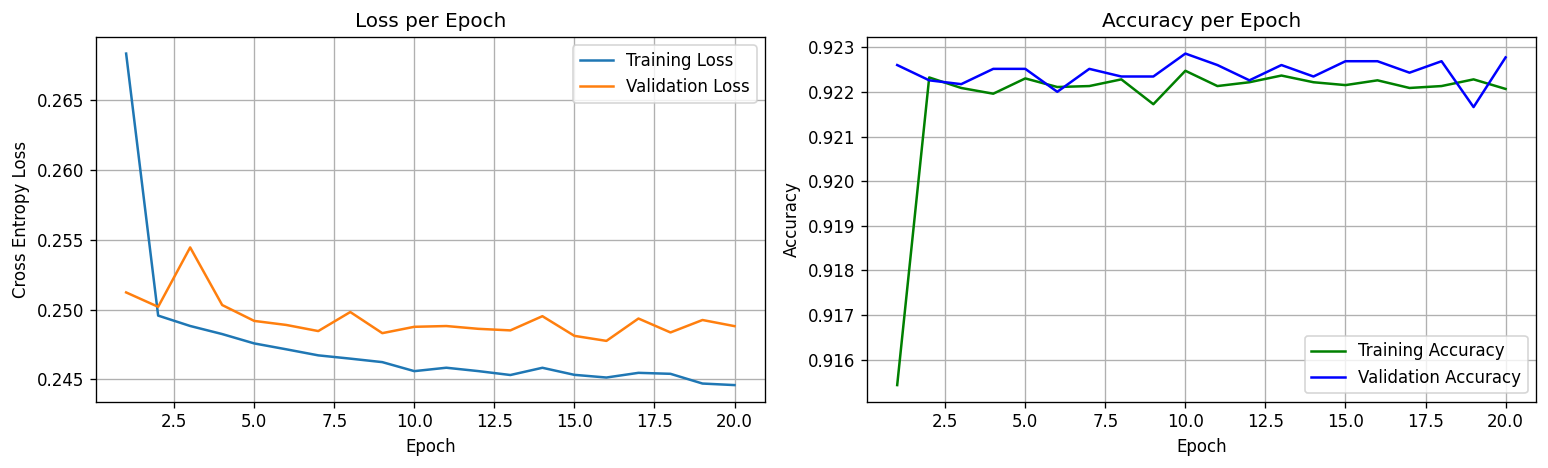

In [ ]:

def plot_training_curves(history_df, savepath='/content/drive/MyDrive/TabTransformer_LossVsAccuracy.pdf'):
    plt.figure(figsize=(13, 4), dpi=120)

    # Loss curve
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(history_df)+1), history_df['loss'], label='Training Loss')
    plt.plot(range(1, len(history_df)+1), history_df['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross Entropy Loss')
    plt.title('Loss per Epoch')
    plt.grid(True)
    plt.legend()

    # Accuracy curve
    plt.subplot(1, 2, 2)
    plt.plot(range(1, len(history_df)+1), history_df['accuracy'], label='Training Accuracy', color='green')
    plt.plot(range(1, len(history_df)+1), history_df['val_accuracy'], label='Validation Accuracy', color='blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy per Epoch')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.savefig(savepath, bbox_inches='tight')
    plt.show()


plot_training_curves(history_df)

Accuracy: 0.9224657534246575
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     13467
           1       0.67      0.00      0.00      1133

    accuracy                           0.92     14600
   macro avg       0.79      0.50      0.48     14600
weighted avg       0.90      0.92      0.89     14600



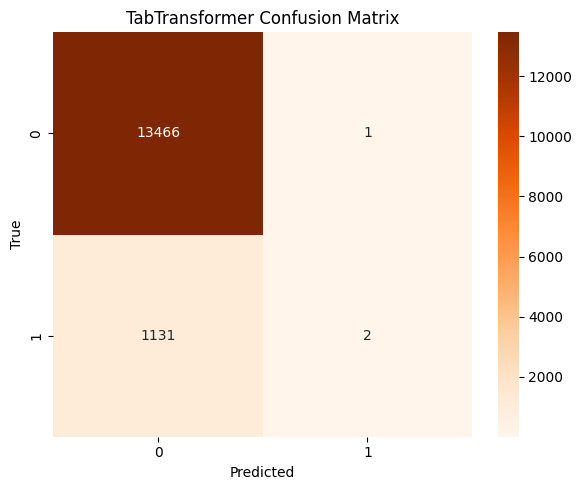

In [ ]:

model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x_cats, x_nums, y in test_loader:
        x_cats, x_nums, y = x_cats.to(device), x_nums.to(device), y.to(device)
        outputs = model(x_cats, x_nums)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("TabTransformer Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/TabTransformer_CM.pdf")
plt.show()


In [ ]:

all_features = categorical_feats + numeric_feats


attn_weights = []
def hook(module, input, output):
    attn_weights.append(module.self_attn.attn_output_weights.detach().cpu())

for layer in model.transformer.layers:
    layer.self_attn.register_forward_hook(hook)


x_cats, x_nums, _ = next(iter(test_loader))
x_cats, x_nums = x_cats.to(device), x_nums.to(device)
_ = model(x_cats, x_nums)


if attn_weights:
    avg_attn = attn_weights[0].mean(dim=0).mean(dim=0).numpy()
    avg_attn = avg_attn[:len(all_features)]
    importance_df = pd.DataFrame({
        "Feature": all_features,
        "Importance": avg_attn / avg_attn.sum()
    }).sort_values(by="Importance", ascending=False)

    print("\nTop features by TabTransformer attention:")
    print(importance_df.head(10))


    plt.figure(figsize=(10,6))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color="salmon")
    plt.gca().invert_yaxis()
    plt.xlabel("Normalized Importance")
    plt.title("TabTransformer Feature Importance")
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/TabTransformer_FeatureImportance.pdf")
    plt.show()


Generating predictions on test set...
Shapes - y_true: (14600,), y_pred: (14600,), y_pred_proba: (14600,)
✅ Shapes match correctly!
Test Accuracy: 0.9225


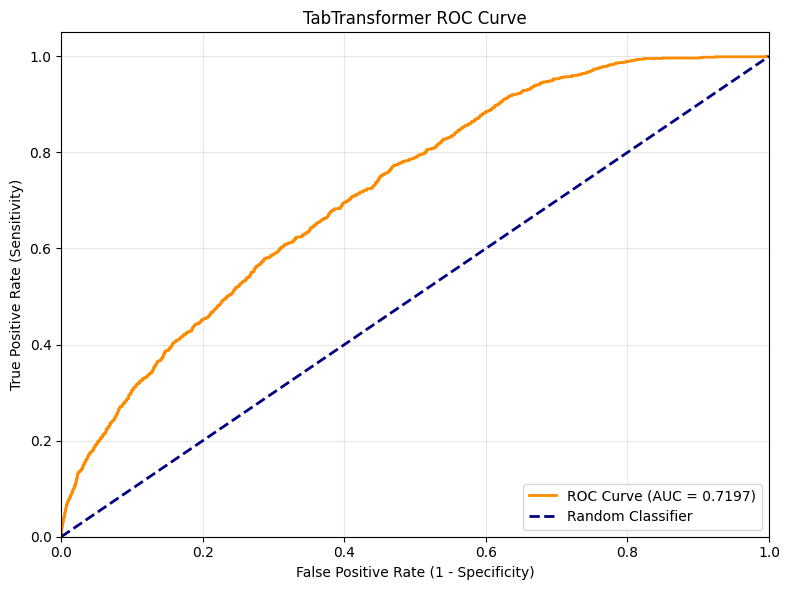

ROC-AUC Score: 0.7197


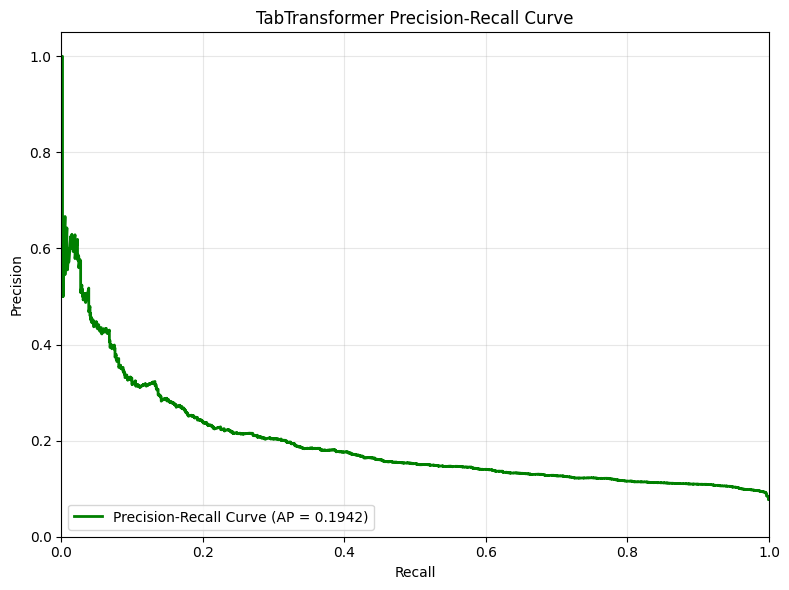

Average Precision Score: 0.1942
Log Loss (Cross-Entropy Loss): 0.304128
Matthews Correlation Coefficient (MCC): 0.036140

COMPREHENSIVE TABTRANSFORMER EVALUATION SUMMARY
Metric                              Value
----------------------------------------
Accuracy                         0.922466
ROC-AUC                          0.719694
Average Precision                0.194230
Log Loss                         0.304128
MCC                              0.036140

✅ Metrics saved to /content/drive/MyDrive/TabTransformer_Metrics_Summary.csv


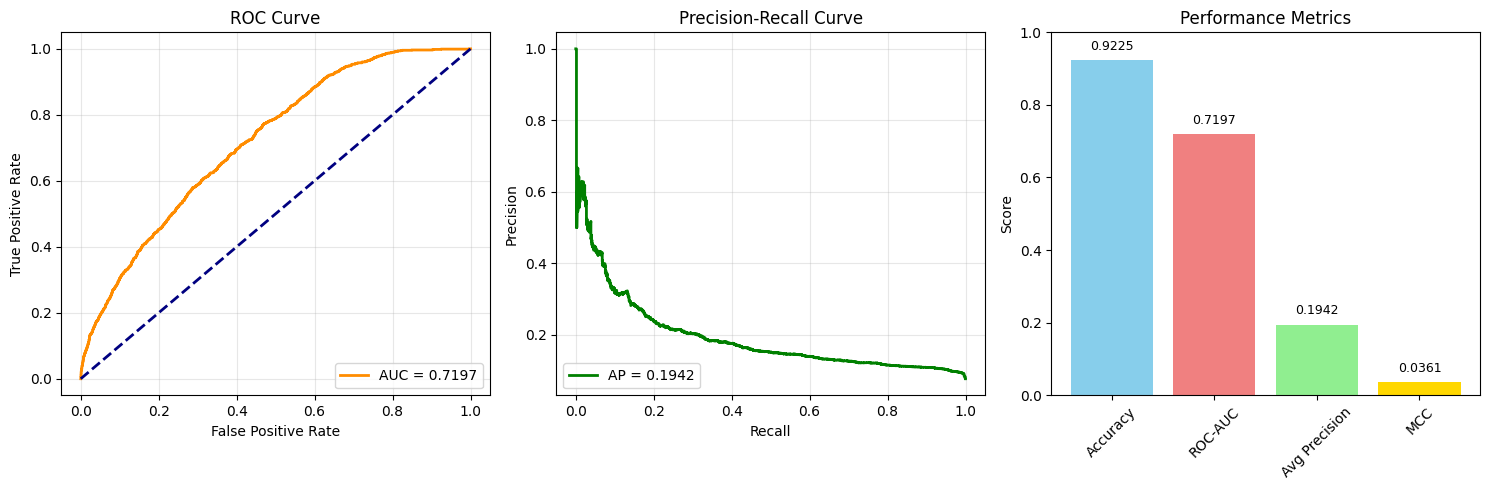


✅ All additional curves and metrics saved to /content/drive/MyDrive/
   - TabTransformer_ROC_Curve.pdf
   - TabTransformer_PrecisionRecall_Curve.pdf
   - TabTransformer_Summary_Metrics.pdf
   - TabTransformer_Metrics_Summary.csv


In [ ]:
# ========== CORRECTED EVALUATION METRICS AND CURVES ==========
# Run this after the debug code

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, matthews_corrcoef, log_loss, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Make sure model is in evaluation mode
model.eval()

# Reset lists
y_true_list = []
y_pred_list = []
y_pred_proba_list = []

print("Generating predictions on test set...")
with torch.no_grad():
    for cats, nums, targets in test_loader:
        cats, nums, targets = cats.to(device), nums.to(device), targets.to(device)
        outputs = model(cats, nums)

        # CRITICAL FIX: Output has 2 columns, take probability for class 1 (index 1)
        probas = torch.sigmoid(outputs)[:, 1]  # This gives probability of positive class (Preterm=1)

        # Get predictions (threshold 0.5)
        preds = probas > 0.5

        y_true_list.extend(targets.cpu().numpy().flatten())
        y_pred_list.extend(preds.cpu().numpy())
        y_pred_proba_list.extend(probas.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_pred_proba = np.array(y_pred_proba_list)

print(f"Shapes - y_true: {y_true.shape}, y_pred: {y_pred.shape}, y_pred_proba: {y_pred_proba.shape}")

# Verify shapes match (should both be 14600)
if y_true.shape != y_pred.shape:
    print(f"ERROR: Shape mismatch! y_true: {y_true.shape}, y_pred: {y_pred.shape}")
else:
    print(f"✅ Shapes match correctly!")

# Calculate accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# 1. ROC CURVE
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('TabTransformer ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TabTransformer_ROC_Curve.pdf', bbox_inches='tight')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

# 2. PRECISION-RECALL CURVE
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_proba)
average_precision = average_precision_score(y_true, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'Precision-Recall Curve (AP = {average_precision:.4f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('TabTransformer Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TabTransformer_PrecisionRecall_Curve.pdf', bbox_inches='tight')
plt.show()

print(f"Average Precision Score: {average_precision:.4f}")

# 3. LOG LOSS (Cross-Entropy Loss)
eps = 1e-15
y_pred_proba_clipped = np.clip(y_pred_proba, eps, 1 - eps)
log_loss_value = log_loss(y_true, y_pred_proba_clipped)
print(f"Log Loss (Cross-Entropy Loss): {log_loss_value:.6f}")

# 4. MATTHEWS CORRELATION COEFFICIENT (MCC)
mcc = matthews_corrcoef(y_true, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.6f}")

# 5. COMPREHENSIVE RESULTS SUMMARY
print("\n" + "="*60)
print("COMPREHENSIVE TABTRANSFORMER EVALUATION SUMMARY")
print("="*60)
print(f"{'Metric':<25} {'Value':>15}")
print("-"*40)
print(f"{'Accuracy':<25} {acc:>15.6f}")
print(f"{'ROC-AUC':<25} {roc_auc:>15.6f}")
print(f"{'Average Precision':<25} {average_precision:>15.6f}")
print(f"{'Log Loss':<25} {log_loss_value:>15.6f}")
print(f"{'MCC':<25} {mcc:>15.6f}")
print("="*60)

# 6. Save metrics to CSV
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC', 'Average Precision', 'Log Loss', 'MCC'],
    'Value': [acc, roc_auc, average_precision, log_loss_value, mcc]
})
metrics_df.to_csv('/content/drive/MyDrive/TabTransformer_Metrics_Summary.csv', index=False)
print("\n✅ Metrics saved to /content/drive/MyDrive/TabTransformer_Metrics_Summary.csv")

# 7. Summary Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
axes[1].plot(recall, precision, color='green', lw=2, label=f'AP = {average_precision:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

# Metrics Bar Chart
metrics_names = ['Accuracy', 'ROC-AUC', 'Avg Precision', 'MCC']
metrics_values = [acc, roc_auc, average_precision, mcc]
colors_bar = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
bars = axes[2].bar(metrics_names, metrics_values, color=colors_bar)
axes[2].set_ylim([0, 1])
axes[2].set_ylabel('Score')
axes[2].set_title('Performance Metrics')
axes[2].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TabTransformer_Summary_Metrics.pdf', bbox_inches='tight')
plt.show()

print("\n✅ All additional curves and metrics saved to /content/drive/MyDrive/")
print("   - TabTransformer_ROC_Curve.pdf")
print("   - TabTransformer_PrecisionRecall_Curve.pdf")
print("   - TabTransformer_Summary_Metrics.pdf")
print("   - TabTransformer_Metrics_Summary.csv")